# Part 1 — Investigating Target Variable 

### Because: 
- It defines the prediction problem.
- It influences evaluation.
- It may require transformation.
- Many later decisions depend on it.

### Import required libraries and load training and testing data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [2]:
train_df.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Generate Histogram of SalePrice

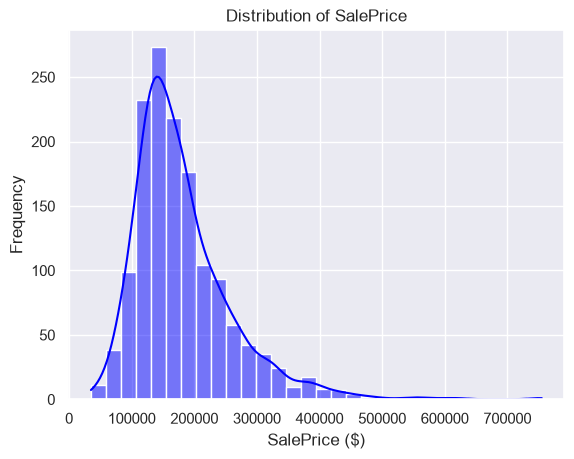

In [3]:
sns.histplot(train_df.SalePrice, kde=True, color="blue", bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice ($)")
plt.ylabel("Frequency")
plt.show()


### Generating Box plot of SalePrice

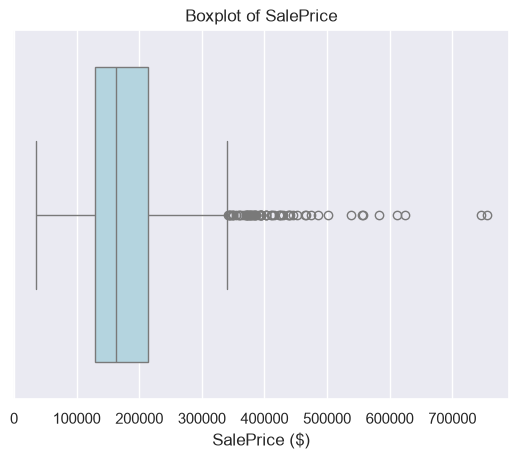

In [4]:
sns.boxplot(x=train_df.SalePrice, color="lightblue")
plt.title("Boxplot of SalePrice")
plt.xlabel("SalePrice ($)")
plt.show()

## Observations:
- Mean (180,921) is greater than the median (163,000), suggests the distribution may be positively (right) skewed.
- 75% of houses cost at most $214,000.
- A relatively small number of expensive houses create a long right tail toward higher sale prices. This suggests the distribution is positively skewed. (Maximun - 75th percentile is around 541,000)
- Median and IQR because the mean gets pulled by extreme values.
- Many regression algorithms perform better when the target is closer to a bell-shaped distribution, so log transformation would make the target distribution more suitable for modeling
- Several high-value outliers are visible in the box plot
- Most houses are concentrated between approximately $100,000 and $250,000. 
- The IQR is 84025

Notet: To manually inspect all 80 features one by one is slow and repetitive way. Instead, they summarize the dataset first and then prioritize which features deserve deeper investigation.

# Part-2 Dataset-Wide Feature Summary

#### Get count of different datatypes in the dataset

In [5]:
train_df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

#### Get the numerical features

In [6]:
numerical_cols = train_df.select_dtypes(include=["number"]).columns
print(numerical_cols)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')


#### Get the categorical features

In [7]:
categorical_cols = train_df.select_dtypes(include=['object', 'category', 'string']).columns
print(categorical_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


#### Get the number of null values per features

In [8]:
null_count = train_df.isnull().sum()
null_count = null_count[null_count > 0].sort_values(ascending = False) 
null_count_df = pd.DataFrame({'column_name': null_count.index, 'null_count': null_count.values})
null_count_df['null_count_percentage'] = (null_count_df['null_count'] / train_df.shape[0]) * 100
print(null_count_df
)

     column_name  null_count  null_count_percentage
0         PoolQC        1453              99.520548
1    MiscFeature        1406              96.301370
2          Alley        1369              93.767123
3          Fence        1179              80.753425
4     MasVnrType         872              59.726027
5    FireplaceQu         690              47.260274
6    LotFrontage         259              17.739726
7     GarageType          81               5.547945
8    GarageYrBlt          81               5.547945
9   GarageFinish          81               5.547945
10    GarageQual          81               5.547945
11    GarageCond          81               5.547945
12  BsmtExposure          38               2.602740
13  BsmtFinType2          38               2.602740
14      BsmtQual          37               2.534247
15      BsmtCond          37               2.534247
16  BsmtFinType1          37               2.534247
17    MasVnrArea           8               0.547945
18    Electr

#### Get the number of unique values per feature

In [9]:
train_df.nunique().sort_values(ascending = False)

Id              1460
LotArea         1073
GrLivArea        861
BsmtUnfSF        780
1stFlrSF         753
                ... 
BsmtHalfBath       3
Utilities          2
Street             2
Alley              2
CentralAir         2
Length: 81, dtype: int64

#### Get the number of unique features for Categorical features only

In [10]:
train_df[categorical_cols].nunique().sort_values(ascending = False) 

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64

#### To get the unique values and their frequency in the Neighbourhood feature

In [11]:
print(train_df['Neighborhood'].value_counts(dropna=False))

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64


#### Get correlation of features with SalePrice

> **NOTE:**
> Correlation only measures linear relationships. So a feature can also have a  non-linear relationship with SalePrice

In [12]:
# Expensive as correlation matrix is N X N, 

# train_df[numerical_cols].corr()["SalePrice"].sort_values(ascending=False)
train_df[numerical_cols].corrwith(train_df["SalePrice"]).sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
dtype: float

# Part 3 — Univariate Feature Analysis

In [13]:
train_df.OverallQual.describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

In [14]:
OverallQual_counts = train_df['OverallQual'].value_counts(dropna = False)
print(OverallQual_counts)

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64


<Axes: xlabel='OverallQual', ylabel='count'>

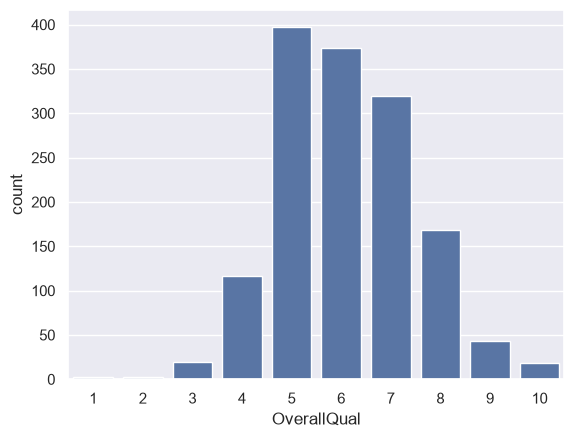

In [15]:
#OverallQual_counts.sort_index().plot(kind='bar', color='lightblue')
sns.countplot(x='OverallQual', data = train_df)

- Most houses are rated around 5–7, indicating that the dataset is dominated by average to good quality homes. 
- Very high-quality houses are relatively rare. 
- Very low-quality houses are extremely rare.
- Categories 1 and 2 are rare. This appears reasonable because very poor-quality houses are uncommon in the dataset. Need to be careful during modeling, since models may have limited examples to learn from these categories.
- Analysing indivdual feature cannot give much clarity, so no need to repeat the process for other 79 variables.

In [16]:
train_df['OverallQual'].isnull().sum()

np.int64(0)

## Feature vs Target Analysis (Bivariate EDA)
### OverallQual vs SalePrice

Text(0.5, 1.0, 'Distribution of Sale Price by Overall Quality')

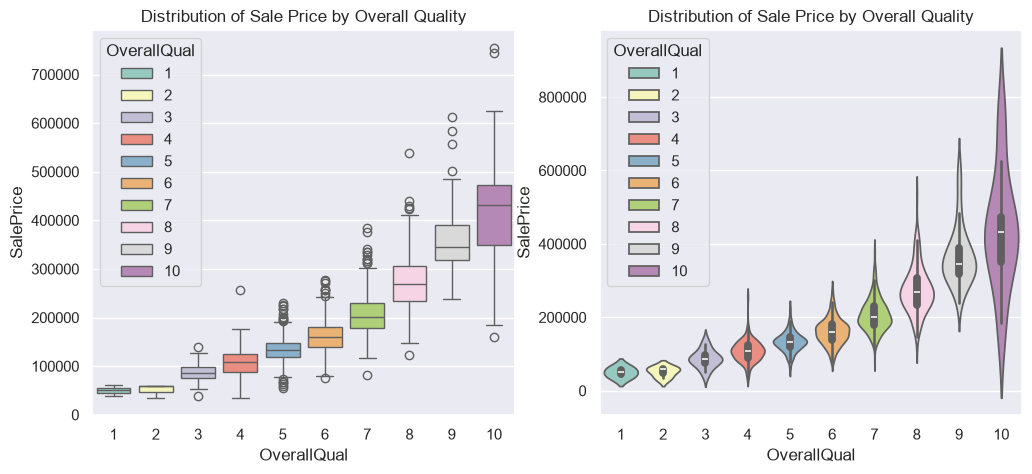

In [17]:
#Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=train_df, x='OverallQual', y='SalePrice', hue='OverallQual', palette="Set3", ax=axes[0])
sns.violinplot(data=train_df, x='OverallQual', y='SalePrice', hue='OverallQual', palette="Set3", ax=axes[1])
axes[0].set_title("Distribution of Sale Price by Overall Quality")
axes[1].set_title("Distribution of Sale Price by Overall Quality")

In [18]:
train_df[train_df['OverallQual'] == 1].SalePrice.describe()

count        2.000000
mean     50150.000000
std      15344.217152
min      39300.000000
25%      44725.000000
50%      50150.000000
75%      55575.000000
max      61000.000000
Name: SalePrice, dtype: float64

#### Observations: 
**OverallQual vs SalePrice**

- Median sale price increases consistently with OverallQual, indicating a strong positive monotonic relationship. (This justifies Correlation = 0.79)
- The relationship appears nonlinear rather than perfectly linear.
- Higher-quality homes exhibit greater variability in sale prices, suggesting that additional factors influence the prices of luxury properties.
- Low-quality categories (1 and 2) contain very few observations and should be interpreted with caution.
- Several high-price outliers are visible, particularly among quality levels 5 and above.
- As the median increases so does the IQR this implies the uncertanity increases as quality increases. In other words the prediction problem actually becomes harder for luxury homes.

### **TotalBsmtSF vs SalePrice and GarageArea vs SalePrice (Moving towards Multivariate EDA):**
> TotalBsmtSF: Total square feet of basement area

#### **TotalBsmtSF vs SalePrice**

In [19]:
#print(train_df["TotalBsmtSF"].head())

# Summary statistics of TotalBsmtSF column
print(train_df['TotalBsmtSF'].describe(), end = "\n\n")

# Summary statistics of TotalBsmtSF column for houses with a basement
print(train_df[train_df['TotalBsmtSF'] > 0]['TotalBsmtSF'].describe(), end = "\n\n")

# Check for null values in TotalBsmtSF column
print(train_df['TotalBsmtSF'].isnull().sum())

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

count    1423.000000
mean     1084.924104
std       409.413709
min       105.000000
25%       810.500000
50%      1004.000000
75%      1309.500000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

0


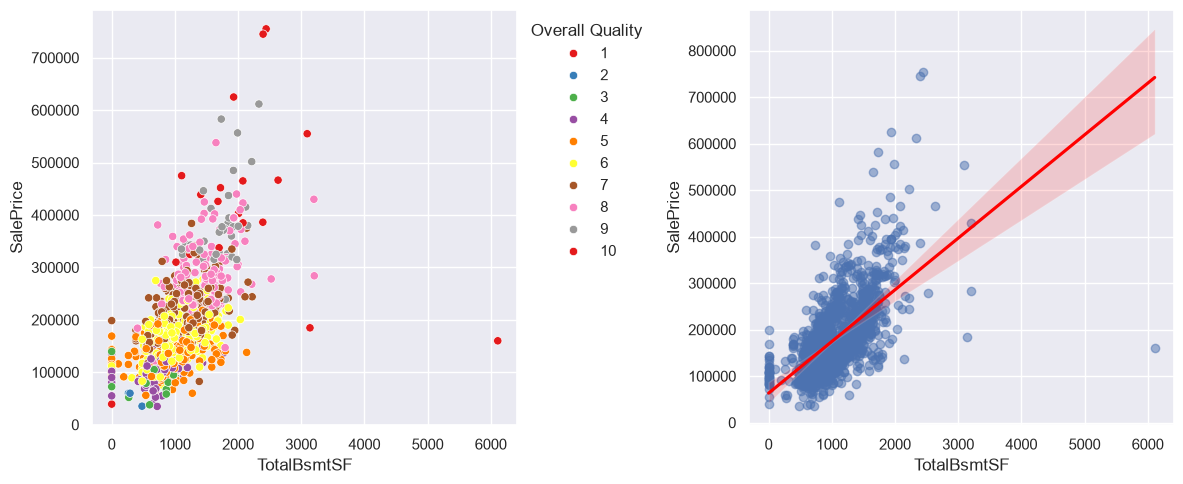

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=train_df, x='TotalBsmtSF', y='SalePrice', hue='OverallQual', palette="Set1", ax=ax[0])
# Move legend outside the top-right corner

# AI Generated:
#Now sns.move_legend can find 'ax'!
sns.move_legend(
    ax[0],
    "upper left",
    bbox_to_anchor=(1, 1),
    title="Overall Quality",  # Updated title to match hue
    frameon=False,
)

sns.regplot(data=train_df, x='TotalBsmtSF', y='SalePrice', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=ax[1])

# Final layout adjustment
plt.tight_layout() # Adjusts layout so legend isn't cut off
plt.show()

#### **GarageArea vs SalePrice**

In [21]:
# Summary statistics of GarageArea column
print(train_df['GarageArea'].describe(), end = "\n\n")

# Summary statistics of GarageArea column for houses with a garage
print(train_df[train_df['GarageArea'] > 0]['GarageArea'].describe(), end = "\n\n")

# Check for null values in GarageArea column
print(train_df['GarageArea'].isnull().sum())

count    1460.000000
mean      472.980137
std       213.804841
min         0.000000
25%       334.500000
50%       480.000000
75%       576.000000
max      1418.000000
Name: GarageArea, dtype: float64

count    1379.000000
mean      500.762146
std       185.680520
min       160.000000
25%       380.000000
50%       484.000000
75%       580.000000
max      1418.000000
Name: GarageArea, dtype: float64

0


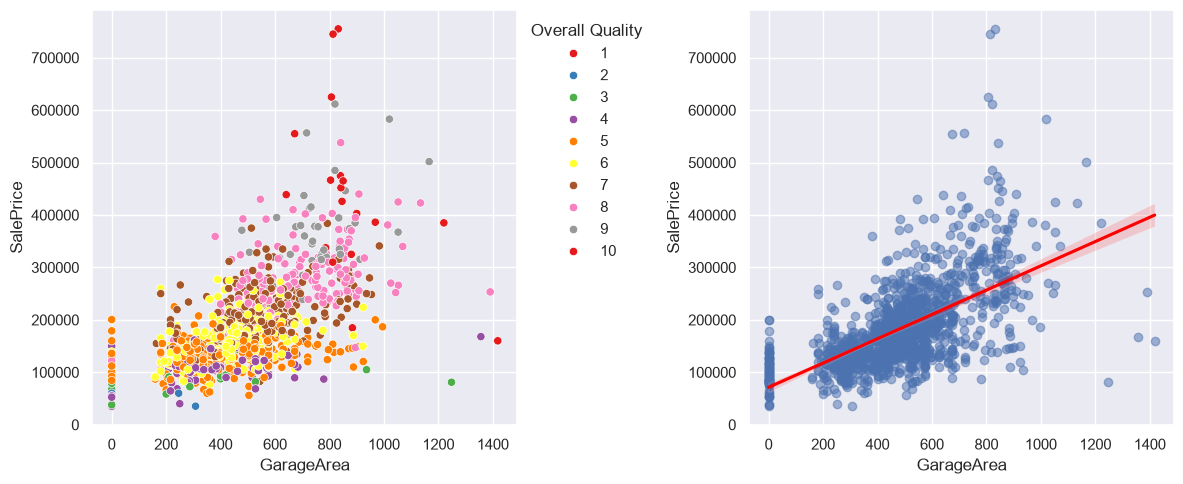

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=train_df, x='GarageArea', y='SalePrice', hue='OverallQual', palette="Set1", ax=ax[0])
# Move legend outside the top-right corner

# AI Generated:
#Now sns.move_legend can find 'ax'!
sns.move_legend(
    ax[0],
    "upper left",
    bbox_to_anchor=(1, 1),
    title="Overall Quality",  # Updated title to match hue
    frameon=False,
)



ax[1] = sns.regplot(data=train_df, x='GarageArea', y='SalePrice', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=ax[1])

# Final layout adjustment
plt.tight_layout() # Adjusts layout so legend isn't cut off
plt.show()

### **All plots together**

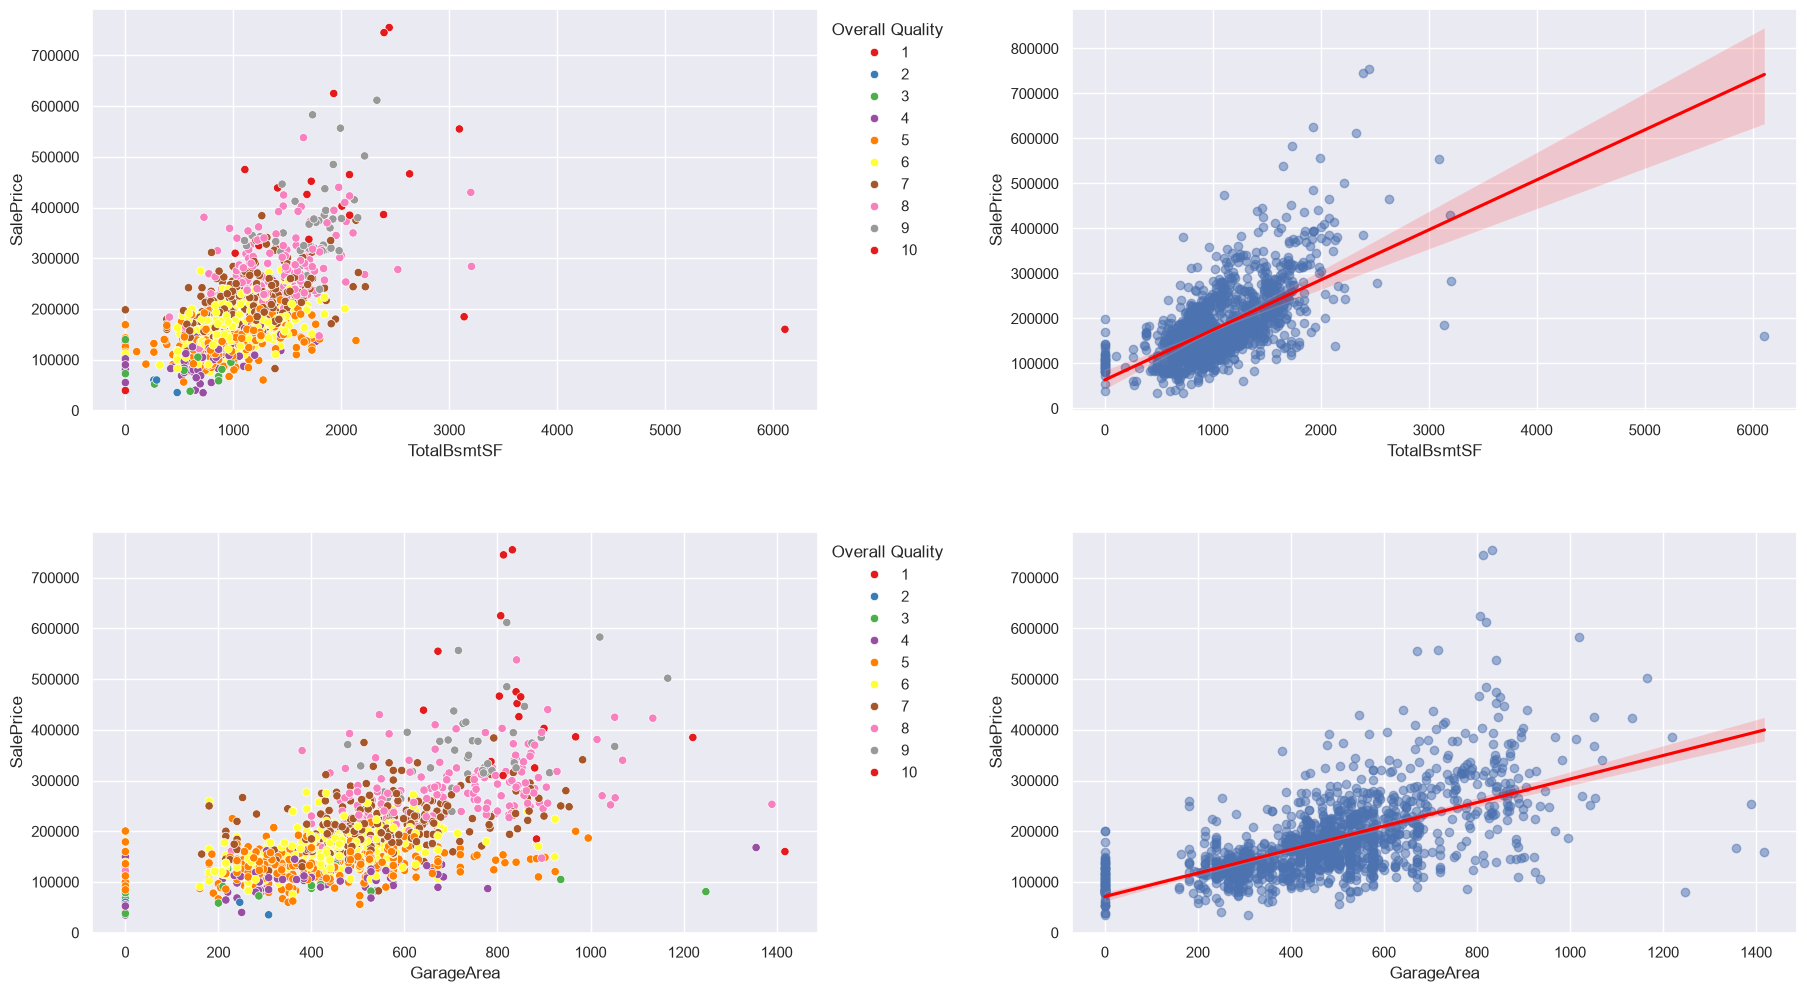

In [32]:
fig, ax = plt.subplots(2, 2, figsize=(22, 12))

#  Row 1: TotalBsmtSF 
sns.scatterplot(data=train_df, x='TotalBsmtSF', y='SalePrice', hue='OverallQual', palette="Set1", ax=ax[0][0])
sns.move_legend(
    ax[0][0],
    "upper left",
    bbox_to_anchor=(1, 1),
    title="Overall Quality",
    frameon=False,
)

sns.regplot(data=train_df, x='TotalBsmtSF', y='SalePrice', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=ax[0][1])


# Row 2: GarageArea 
sns.scatterplot(data=train_df, x='GarageArea', y='SalePrice', hue='OverallQual', palette="Set1", ax=ax[1][0])
sns.move_legend(
    ax[1][0],
    "upper left",
    bbox_to_anchor=(1, 1),
    title="Overall Quality",
    frameon=False,
)

sns.regplot(data=train_df, x='GarageArea', y='SalePrice', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=ax[1][1])


# Adjust spacing to give room for the outside legends
plt.subplots_adjust(wspace=0.35, hspace=0.3)
plt.show()

### **Analysis**
##### **TotalBsmtSF vs SalePrice**

In [51]:
df1 = train_df[train_df['TotalBsmtSF'] > 6000]

df2 = train_df[train_df['SalePrice'] > 700000]

pd.concat([df1, df2], axis=0).drop_duplicates()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


##### **GarageArea vs SalePrice**

In [40]:
train_df.loc[train_df['GarageArea'] > 1200, ['Id', 'GarageArea']]

,Id,GarageArea
581,582,1390
825,826,1220
1061,1062,1248
1190,1191,1356
1298,1299,1418


In [54]:
# i do not think 825 id house can be an outlier, so we need to be careful while removing outliers. We can remove the house with id 825 and GarageArea greater than 1220 as it is an outlier.
df3 = train_df[train_df['GarageArea'] > 1220]

df4 = train_df[train_df['SalePrice'] > 600000]

pd.concat([df3, df4], axis=0).drop_duplicates()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
898,899,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


### **Observations**: TotalBsmtSF vs. SalePrice

1. **Positive Correlation:** There is a strong positive linear relationship between total basement square footage (`TotalBsmtSF`) and `SalePrice`—as basement size increases, house prices systematically increase.
2. **Quality Clustering (`OverallQual` Interaction):** Larger basements are heavily concentrated in higher-quality houses (`OverallQual` 7–10). However, quality bands overlap across basement sizes, showing that basement size contributes to house quality but does not fully dictate it.
3. **Zero-Basement Floor ($0\text{ sq ft}$):** Properties with `TotalBsmtSF = 0` represent homes built without basements. While they span a range of overall quality levels (ratings 3 to 8), their sale price is strictly capped below $200,000.
4. **Increasing Variance (Heteroscedasticity):** As basement area exceeds 2,000 sq ft, the spread of sale prices widens significantly. This growing variance indicates that for large footprint homes, basement size alone is insufficient to predict price and secondary features play a stronger role.
5. **High-Leverage Outlier Candidates:** Extreme observations warrant investigation rather than immediate deletion:
   * **`Id: 1298`**: Displays an extreme basement size (> 6,000 sq ft) paired with an unusually low price ($160,000), strongly suggesting a distressed sale or abnormal transaction condition (`SaleCondition`).
   * **`Id: 691` & `1182`**: Represent legitimate high-end luxury mansions ($700,000+) rather than data errors.

---

### **Observations**: GarageArea vs. SalePrice

1. **Positive Baseline Driver:** `GarageArea` shows a general positive relationship with `SalePrice`, serving as another functional square-footage driver of price.
2. **Weak Coupling with Quality:** Unlike basement size, garage capacity is weakly tied to build quality. At a common size of ~700 sq ft, overall quality ranges from 3 all the way to 10. This indicates garage area is primarily a functional utility rather than a direct indicator of luxury tier.
3. **Zero-Garage Cap ($0\text{ sq ft}$):** Properties lacking a garage (`GarageArea = 0`) have a price ceiling capped at $200,000, matching the pattern seen in foundation-less homes.
4. **Diminishing Returns & Variance:** Price variance increases noticeably for garage areas over 1,000 sq ft, showing signs of diminishing returns where extra garage space stops yielding linear price increases.
5. **Outlier Strategy:** High-footprint homes like `Id: 1298` show extreme leverage across both basement and garage features. Rather than blindly wiping high-leverage rows, they should be flagged and tested via model sensitivity analysis.

---

### Synthesis & Modeling Takeaways

* **Multivariate Insight:** Bivariate plots alone showed heavy scatter, but adding `OverallQual` as a hue revealed clear structural sub-groups. Tree-based models (XGBoost, Random Forest) will be ideal here as they naturally capture feature interactions.
* **Target Variance:** The expanding price spread at higher square footages confirms heteroscedasticity, supporting the use of a log transformation on `SalePrice` ($\log(1 + y)$) during preprocessing.
* **Non-Zero Absence Signals:** Features with 0 sq ft represent structural physical traits (e.g., no basement/garage) rather than missing data (`NaN`).

# EDA Summary and Key Findings

- OverallQual, GarageArea, TotalBsmtSF have positive relationship. These were selected because they also showed relatively strong correlations with SalePrice during our initial screening.
- Based on the analyses performed so far, these features appear promising, but additional modeling and feature importance analyses will provide stronger evidence.
- Potential outliers have been identified and should be investigated further before deciding whether any treatment is necessary.
- We need not delete the outliers we need to 1st understand why those are acting as outliers maybe there is some feature which is making those values look as if they are anomalies so we need to figure out that perhaps during preprocessing.
- Hypotheses that influence the modeling pipeline:
    * The target is positively skewed, so a log transformation may improve model performance.
    * Missing values in PoolQC likely represent the absence of a pool and should be encoded accordingly rather than dropped.
    * OverallQual is likely to be one of the most influential predictors.
    * Outliers should be reviewed individually before applying any removal strategy.
    * Feature engineering based on house age may improve predictive performance.
- They're hypotheses about the data, and they guide how we preprocess and engineer features.
- These observations will guide the preprocessing phase, including handling missing values, investigating potential outliers, and engineering informative features.